STUDENT PERFORMANCE INDICATOR

### Life cycle of Machine Learning Project

* Understanding the problem statement
* Data collection
* Data checks to perform
* Exploratory Data Analysis
* Data Pre - processing
* Model Training
* Choose Best Model

### 1) Problem statement

* This project understand how student performance is affected by other variables like Gender , Ethnicity , Parental level of education and Test preparation course

### 2) Data Collection

* Dataset source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977 
* This contains 8 cols and 1000 rows

#### 2.1 Import Required Packages and Data

Numpy , Pandas , Matplotlib , Seaborn and Warnings Libary

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from IPython.core.pylabtools import figsize
from pygments.lexers.templates import GenshiMarkupLexer
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
student_performance_data = pd.read_csv('data/StudentsPerformance.csv')

In [3]:
student_performance_data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
student_performance_data['test preparation course'].unique()

<StringArray>
['none', 'completed']
Length: 2, dtype: str

### Dataset Information
 * Gender : Male/Female
* Race/Ethnicity : Group (A,B,C,D,E)
* Parental Level Education :  'bachelor's degree','some college','master's degree','associate's degree','high school',   'some high school'
* Lunch : Standard , free/reduced
* Test preparation course : none . completed
* Math score
* Reading score
* Writing score

### Data checks to be performed

1. Check Missing values
2. Check Duplicates
3. Check datatype
4. Check the number of unique values
5. Check the statistics of data set
6. Check various categories present in the different categorical column

#### 3.1 Check missing values

In [5]:
student_performance_data.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

##### There are no missing values in the dataset

#### 3.2 Check duplicates

In [6]:
student_performance_data.duplicated().sum()

np.int64(0)

##### There are no duplicate values in the dataset

#### 3.3 Check Datatypes

In [7]:
student_performance_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


#### 3.4 Check the number of unique values

In [8]:
student_performance_data.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

#### 3.5 Check the statistics of the dataset

In [9]:
student_performance_data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Insights

* All means are close to each other between 66 - 69.16
* All standard deviations are close - between 14.6 - 15.19
* Minimum score in math = 0 < writing = 10 < reading = 17

### 3.7 Exploring Data

In [10]:
print("Categories in 'gender' variable: ",end=" ")
print(student_performance_data['gender'].unique())

print("Categories in 'race/ethnicity' variable: ",end=" ")
print(student_performance_data['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable: ",end=" ")
print(student_performance_data['parental level of education'].unique())

print("Categories in 'lunch' variable: ",end=" ")
print(student_performance_data['lunch'].unique())

print("Categories in 'test preparation course' variable: ",end=" ")
print(student_performance_data['test preparation course'].unique())


Categories in 'gender' variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race/ethnicity' variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental level of education' variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [11]:
# define numerical and categorical features
numerical_features = [feature for feature in student_performance_data.columns
                      if student_performance_data[feature].dtype in ['int64' , 'float64']]

categorical_features = [feature for feature in student_performance_data.columns
                        if student_performance_data[feature].dtype in ['object' , 'string']]

print(f"We have {len(numerical_features)} numerical features")
print(f"Numerical features: {numerical_features}")

print(f"We have {len(categorical_features)} categorical features")
print(f"Categorical features: {categorical_features}")

We have 3 numerical features
Numerical features: ['math score', 'reading score', 'writing score']
We have 5 categorical features
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


### creating "Total Score" and "Average"

In [12]:
# Creating Total score and Average column

student_performance_data['total score'] = student_performance_data['math score']+student_performance_data['reading score']+student_performance_data['writing score']

student_performance_data['average'] = student_performance_data['total score']/3

student_performance_data.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [13]:
print(student_performance_data.dtypes)

gender                             str
race/ethnicity                     str
parental level of education        str
lunch                              str
test preparation course            str
math score                       int64
reading score                    int64
writing score                    int64
total score                      int64
average                        float64
dtype: object


In [14]:
student_performance_data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
reading_full = student_performance_data[student_performance_data['reading score'] == 100]['average'].count()
math_full = student_performance_data[student_performance_data['math score'] == 100]['average'].count()
writing_full = student_performance_data[student_performance_data['writing score'] == 100]['average'].count()

print("No of students who got full marks in")
print(f"Math : {math_full}")
print(f"Reading : {reading_full}")
print(f"Writing : {writing_full}")

No of students who got full marks in
Math : 7
Reading : 17
Writing : 14


In [16]:
reading_less_20 = student_performance_data[student_performance_data['reading score'] < 20]['average'].count()
math_less_20 = student_performance_data[student_performance_data['math score'] < 20]['average'].count()
writing_less_20 = student_performance_data[student_performance_data['writing score'] < 20]['average'].count()

print("No of students who got less than 20 marks in")
print(f"Math : {math_less_20}")
print(f"Reading : {reading_less_20}")
print(f"Writing : {writing_less_20}")

No of students who got less than 20 marks in
Math : 4
Reading : 1
Writing : 3


### Insights

* Students performed well in Reading
* Students didn't perform well in Math

## 4. Data Visualization

* Histogram
* Kernel Distribution Function(KDE)

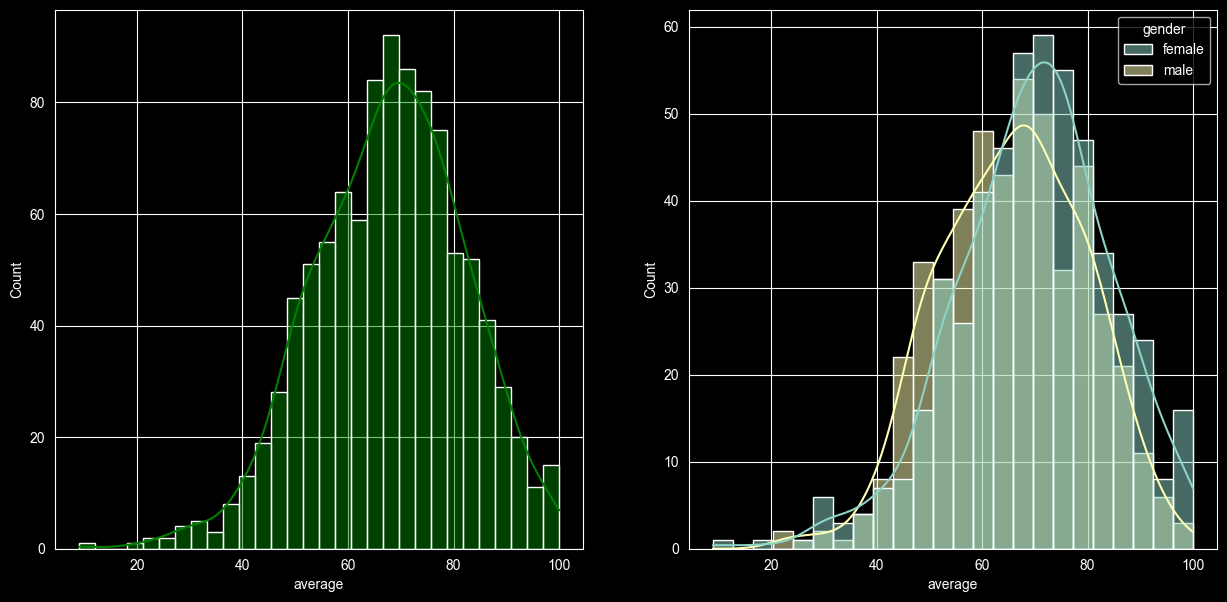

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=student_performance_data, x='average', bins=30, kde=True, color='g', ax=axs[0])

sns.histplot(data=student_performance_data, x='average', kde=True, hue='gender', ax=axs[1])

plt.show()

### Insights

Female students tend to perform good than male students

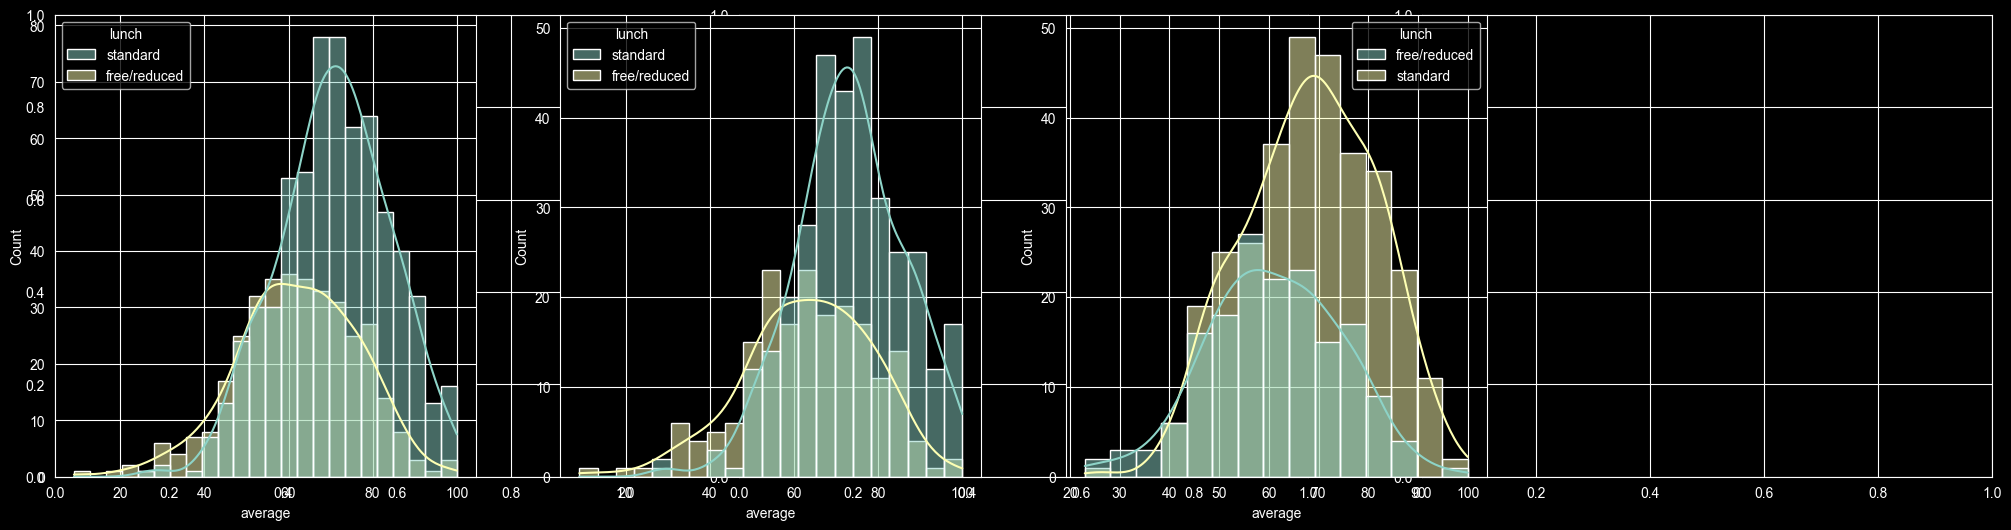

In [20]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=student_performance_data , x='average' , kde=True , hue = 'lunch')
plt.subplot(142)
sns.histplot(data=student_performance_data[student_performance_data.gender == 'female'] , x='average' , kde=True ,hue='lunch')
plt.subplot(143)
sns.histplot(data=student_performance_data[student_performance_data.gender == 'male'] , x='average' , kde=True ,hue='lunch')
plt.show()


### Insights

* Standard lunch helps students to score well in exams
* Standard lunch helps perform well in exams be it a male / female

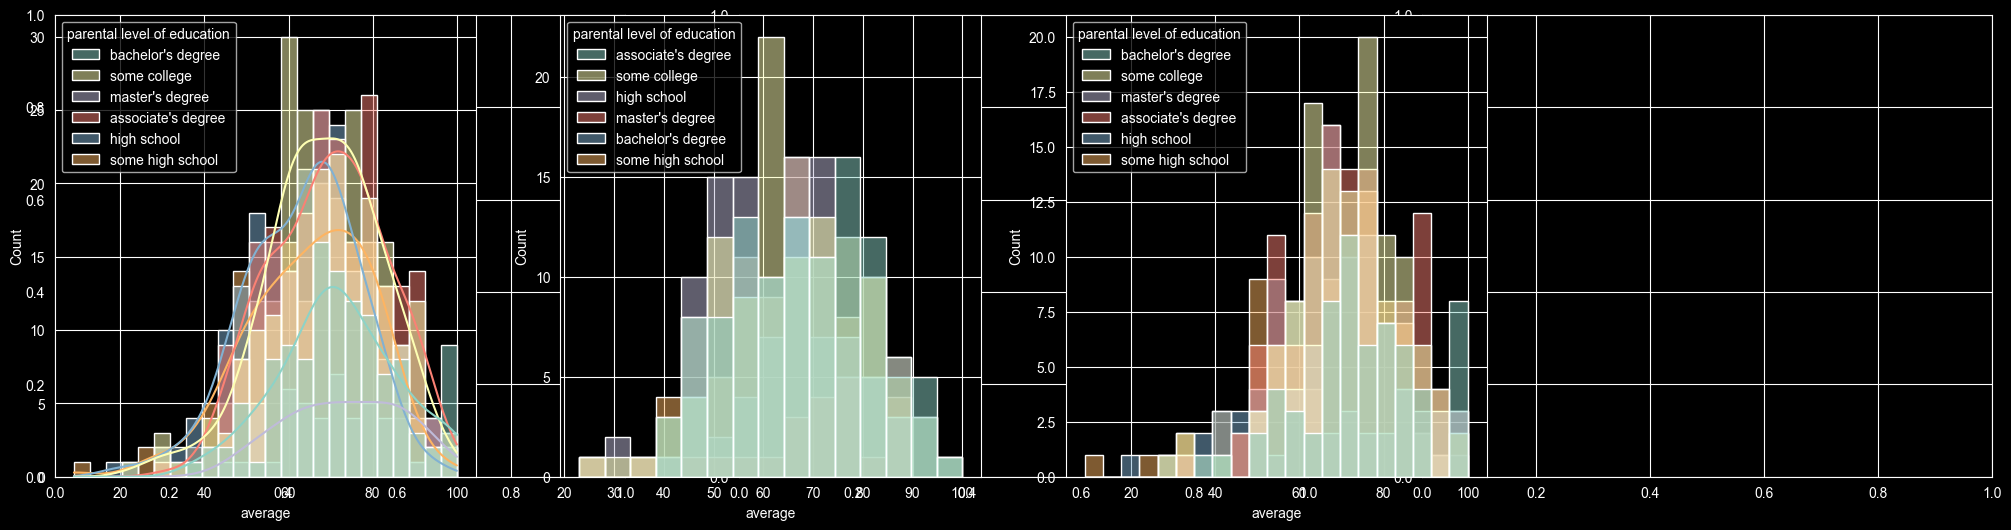

In [22]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=student_performance_data,x='average',kde = True , hue = 'parental level of education')
plt.subplot(142)
sns.histplot(data=student_performance_data[student_performance_data.gender == 'male'],x='average',hue='parental level of education')
plt.subplot(143)
sns.histplot(data=student_performance_data[student_performance_data.gender == 'female'],x='average',hue='parental level of education')
plt.show()

sns.histplot(data=student_performance_data[student_performance_data.gender == 'female'],x='average',hue='parental level of education')

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

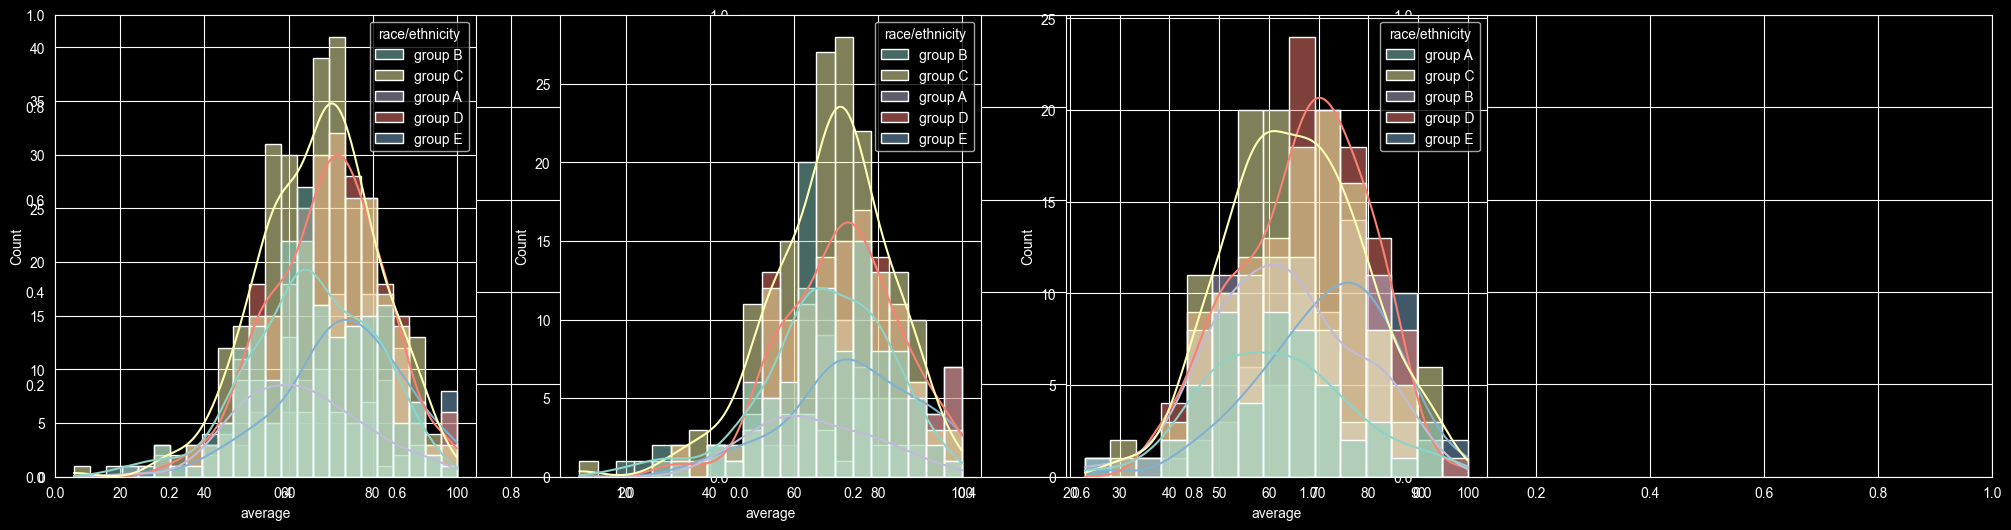

In [25]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=student_performance_data,x='average',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax =sns.histplot(data=student_performance_data[student_performance_data.gender=='female'],x='average',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax =sns.histplot(data=student_performance_data[student_performance_data.gender=='male'],x='average',kde=True,hue='race/ethnicity')
plt.show()

#### Insights

* Group A and Group B doesn't seem to perform well
* Group A and Group B doesn't tend to perform well regardless of male / female

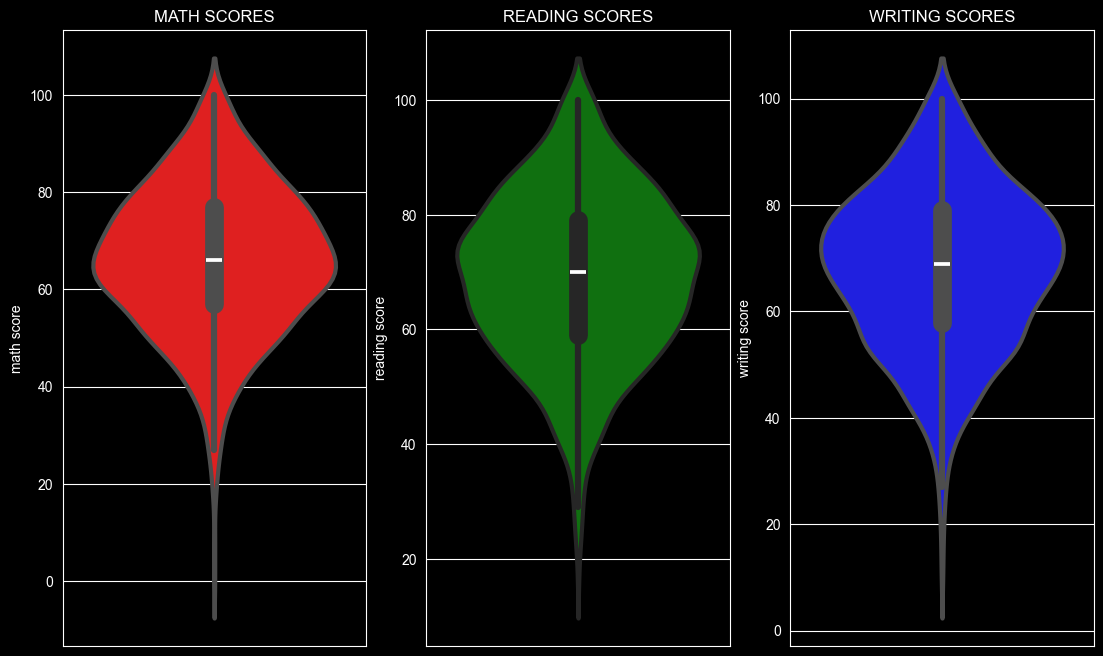

In [26]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=student_performance_data,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=student_performance_data,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=student_performance_data,color='blue',linewidth=3)
plt.show()

#### Insights

* Student's score in math are between 60-80 whereas in reading and writing the score is 50-80

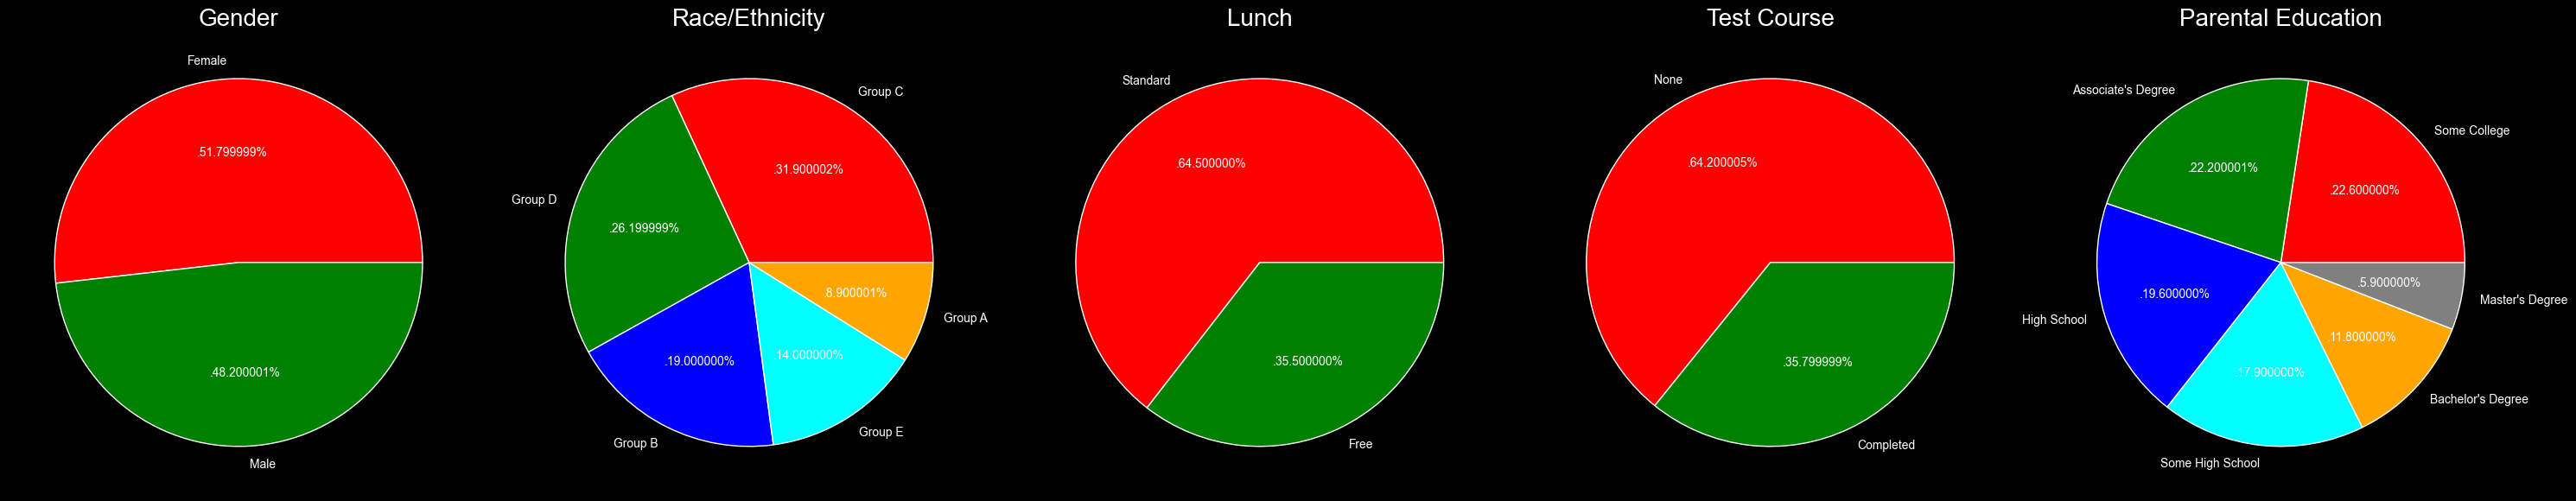

In [27]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = student_performance_data['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Gender', fontsize=20)
plt.axis('off')


plt.subplot(1, 5, 2)
size = student_performance_data['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D', 'Group B', 'Group E', 'Group A'
color = ['red', 'green', 'blue', 'cyan', 'orange']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Race/Ethnicity', fontsize=20)
plt.axis('off')


plt.subplot(1, 5, 3)
size = student_performance_data['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Lunch', fontsize=20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = student_performance_data['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Test Course', fontsize=20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = student_performance_data['parental level of education'].value_counts()
labels = ['Some College', "Associate's Degree", 'High School',
          'Some High School', "Bachelor's Degree", "Master's Degree"]
color = ['red', 'green', 'blue', 'cyan', 'orange', 'grey']

plt.pie(size, colors=color, labels=labels, autopct='.%2f%%')
plt.title('Parental Education', fontsize=20)
plt.axis('off')


plt.tight_layout()
plt.grid()
plt.show()

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

### Feature wise Visualization

#### 4.4.1 GENDER COLUMN

* How's is the distribution of Gender?
* Do Gender have any impact on performance ?

### UNIVARIATE ANALYSIS (How's the distribution of Gender?)

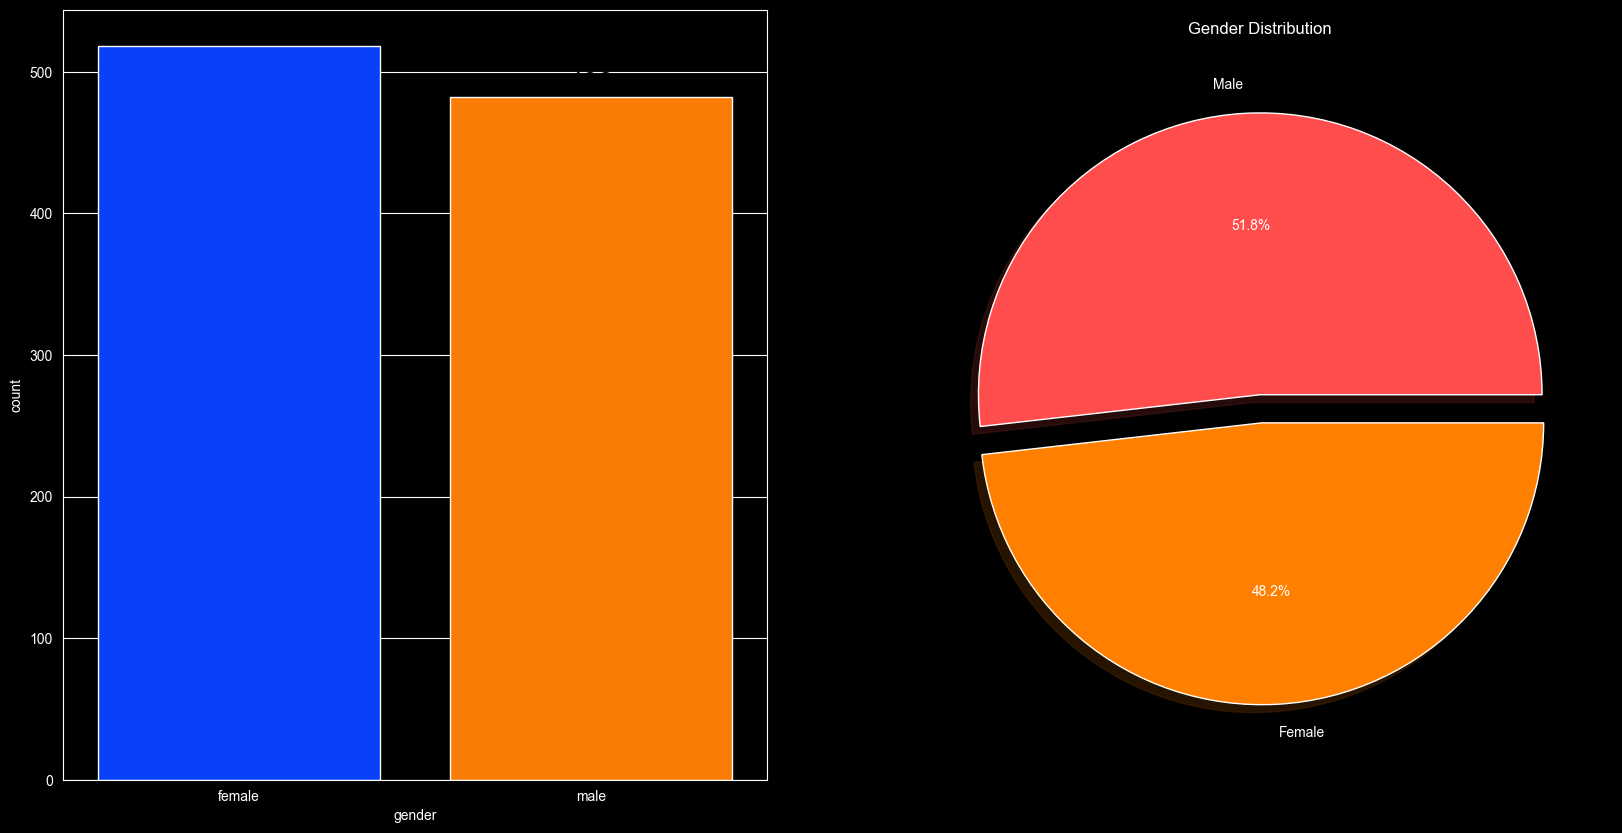

In [31]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(
    x=student_performance_data['gender'],
    data=student_performance_data,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Pie chart on second subplot
ax[1].pie(
    x=student_performance_data['gender'].value_counts(),
    labels=['Male', 'Female'],
    explode=[0, 0.1],
    autopct='%1.1f%%',
    shadow=True,
    colors=['#ff4d4d', '#ff8000']
)

ax[1].set_title('Gender Distribution')

plt.show()

#### Insights

* Female (518 nos - 48%)
* Male (482 nos - 52%)

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? )

In [33]:
gender_group = student_performance_data.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


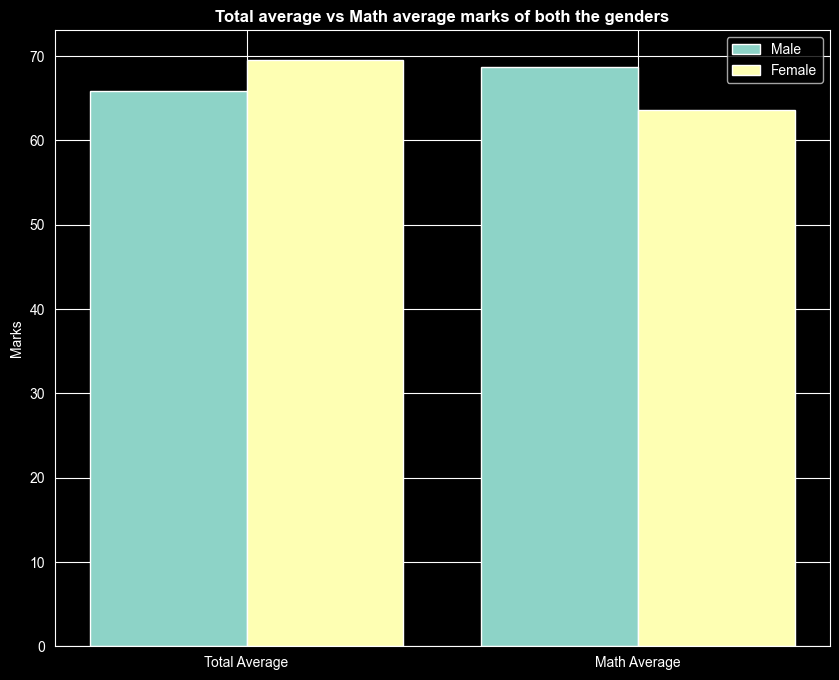

In [34]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math score']
]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average vs Math average marks of both the genders", fontweight='bold')
plt.legend()

plt.show()

#### Insights
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

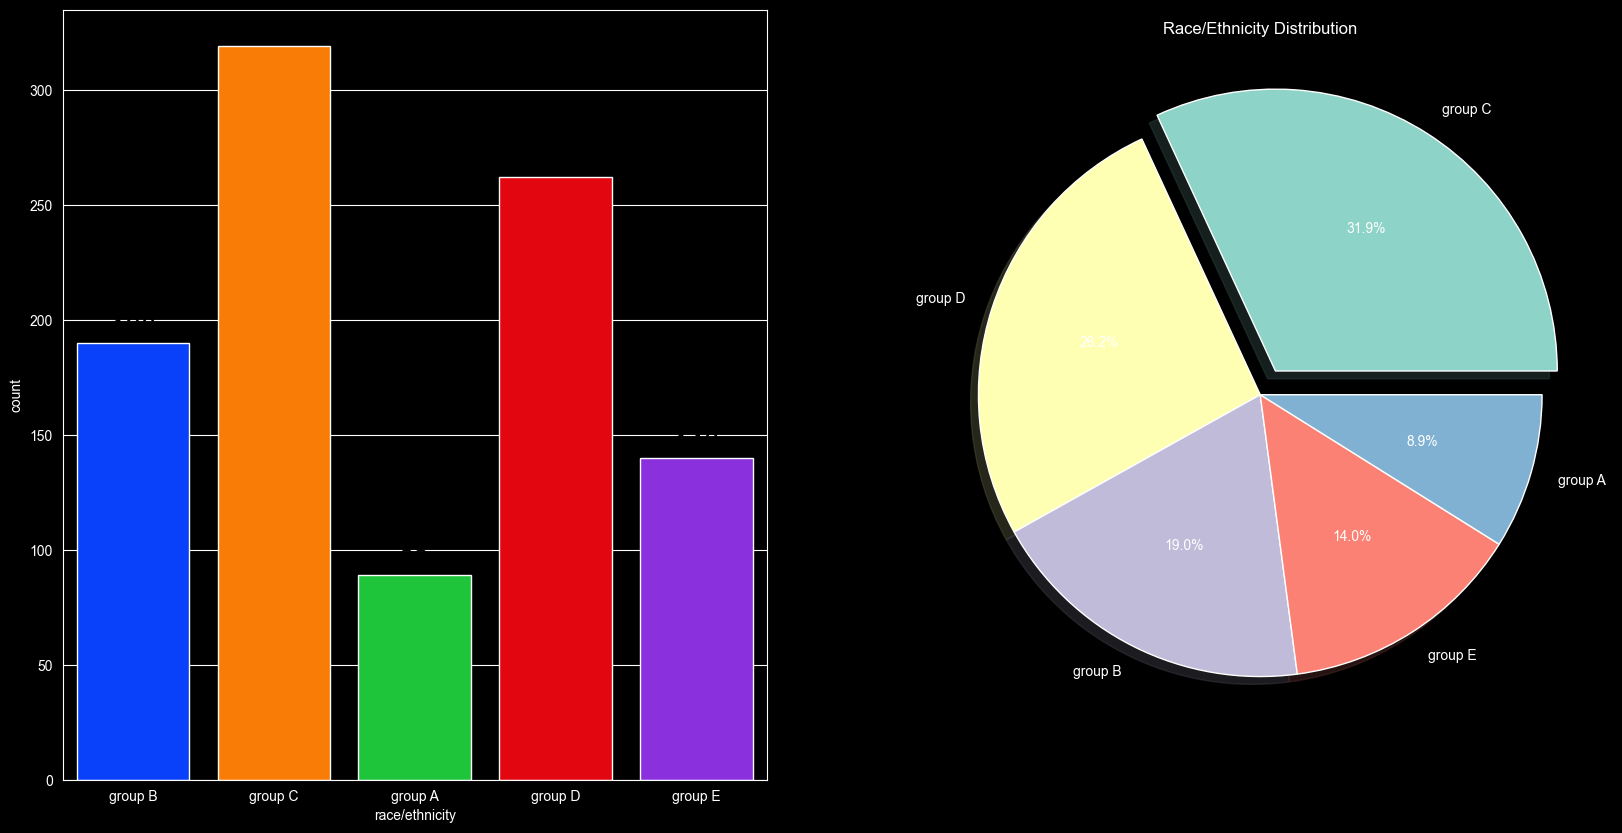

In [37]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.countplot(
    x=student_performance_data['race/ethnicity'],
    data=student_performance_data,
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Pie chart on second subplot
counts = student_performance_data['race/ethnicity'].value_counts()

ax[1].pie(
    x=counts,
    labels=counts.index,
    explode=[0.1, 0, 0, 0, 0],
    autopct='%1.1f%%',
    shadow=True
)

ax[1].set_title('Race/Ethnicity Distribution')

plt.show()

#### Insights
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ethnicity has any impact on student's performance ? )

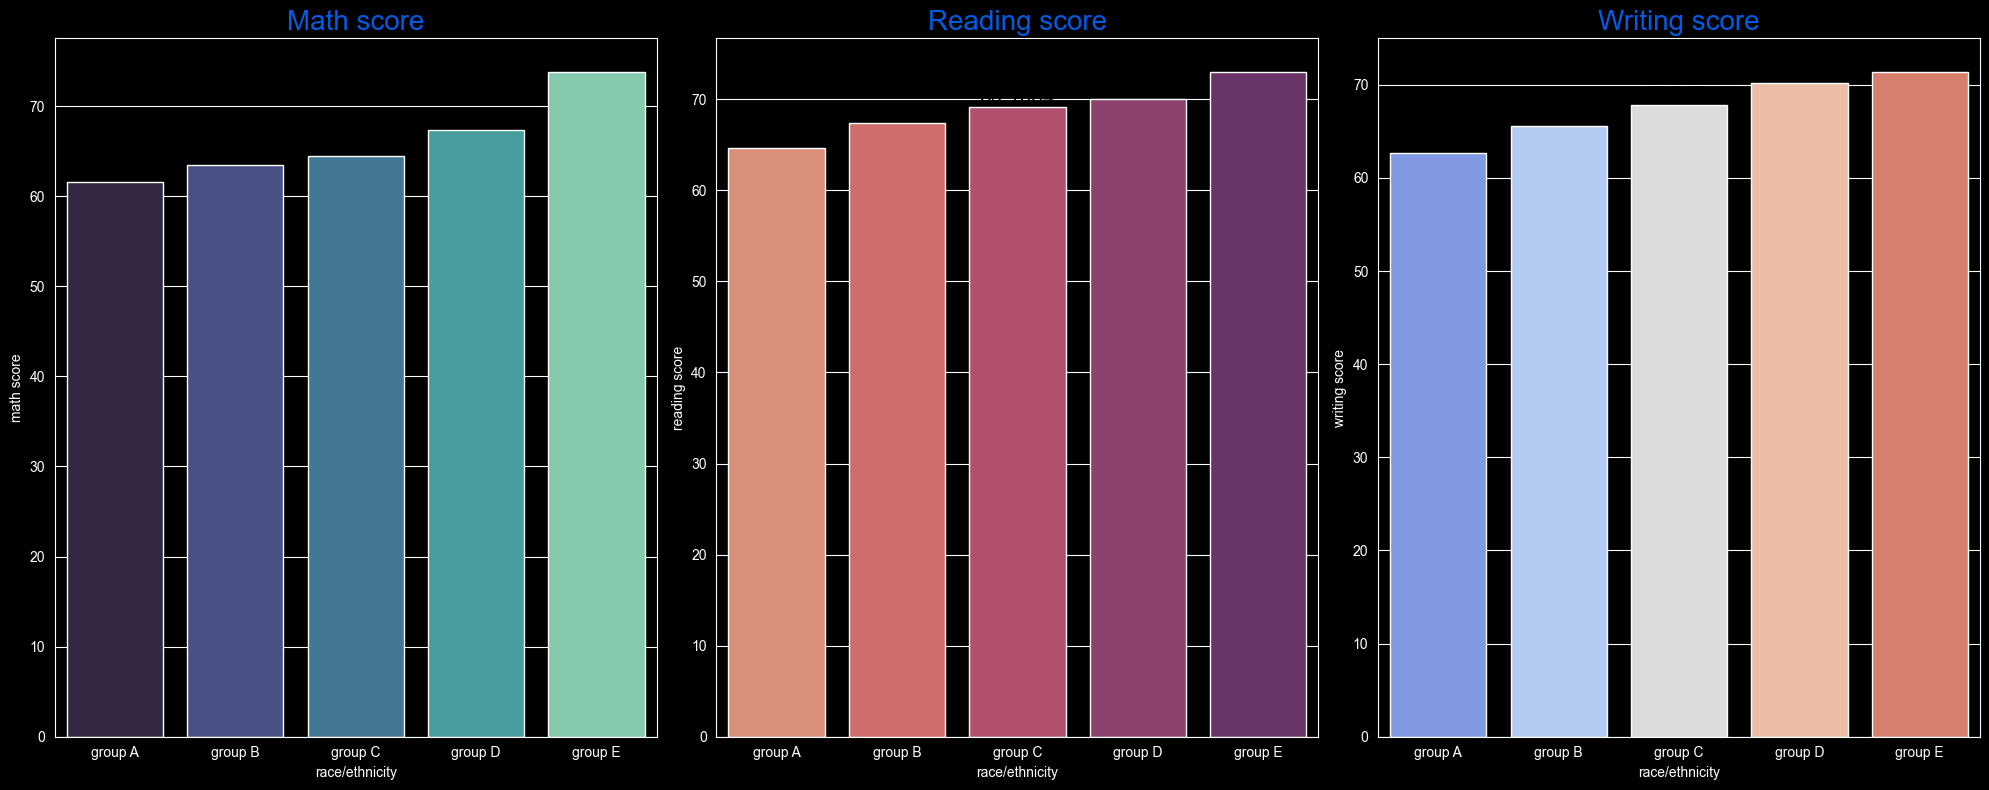

In [39]:
Group_data2 = student_performance_data.groupby('race/ethnicity').mean(numeric_only=True)

f, ax = plt.subplots(1, 3, figsize=(20, 8))

# Math
sns.barplot(
    x=Group_data2.index,
    y=Group_data2['math score'],
    palette='mako',
    ax=ax[0]
)
ax[0].set_title('Math score', color='#005ce6', size=20)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)


# Reading
sns.barplot(
    x=Group_data2.index,
    y=Group_data2['reading score'],
    palette='flare',
    ax=ax[1]
)
ax[1].set_title('Reading score', color='#005ce6', size=20)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', size=15)


# Writing
sns.barplot(
    x=Group_data2.index,
    y=Group_data2['writing score'],
    palette='coolwarm',
    ax=ax[2]
)
ax[2].set_title('Writing score', color='#005ce6', size=20)

for container in ax[2].containers:
    ax[2].bar_label(container, color='black', size=15)

plt.tight_layout()
plt.show()

## Insights

* Group E performs well
* Group E > Group D > Group C > Group B > Group A

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

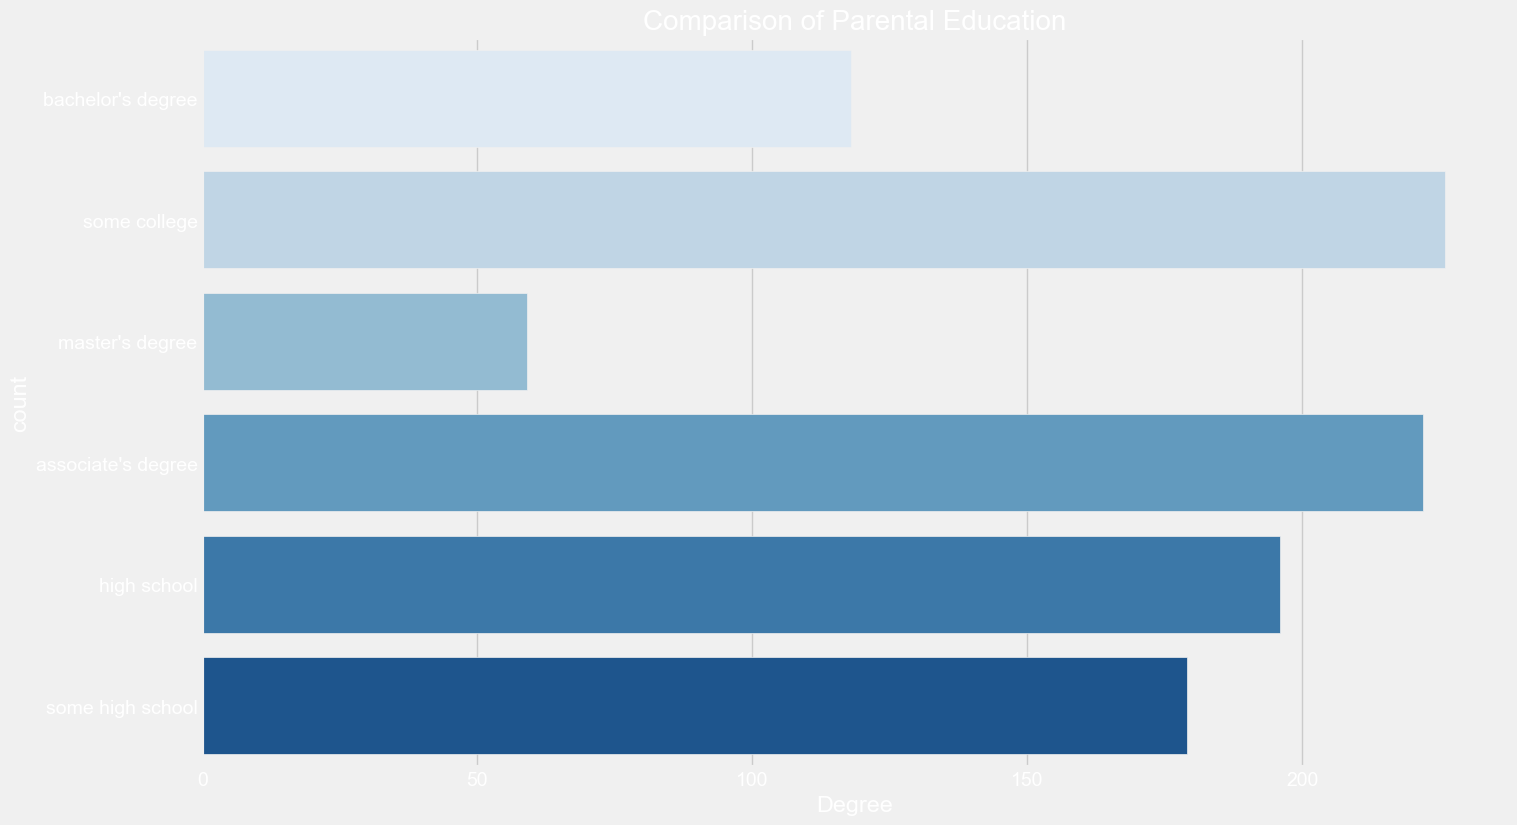

In [40]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(student_performance_data['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

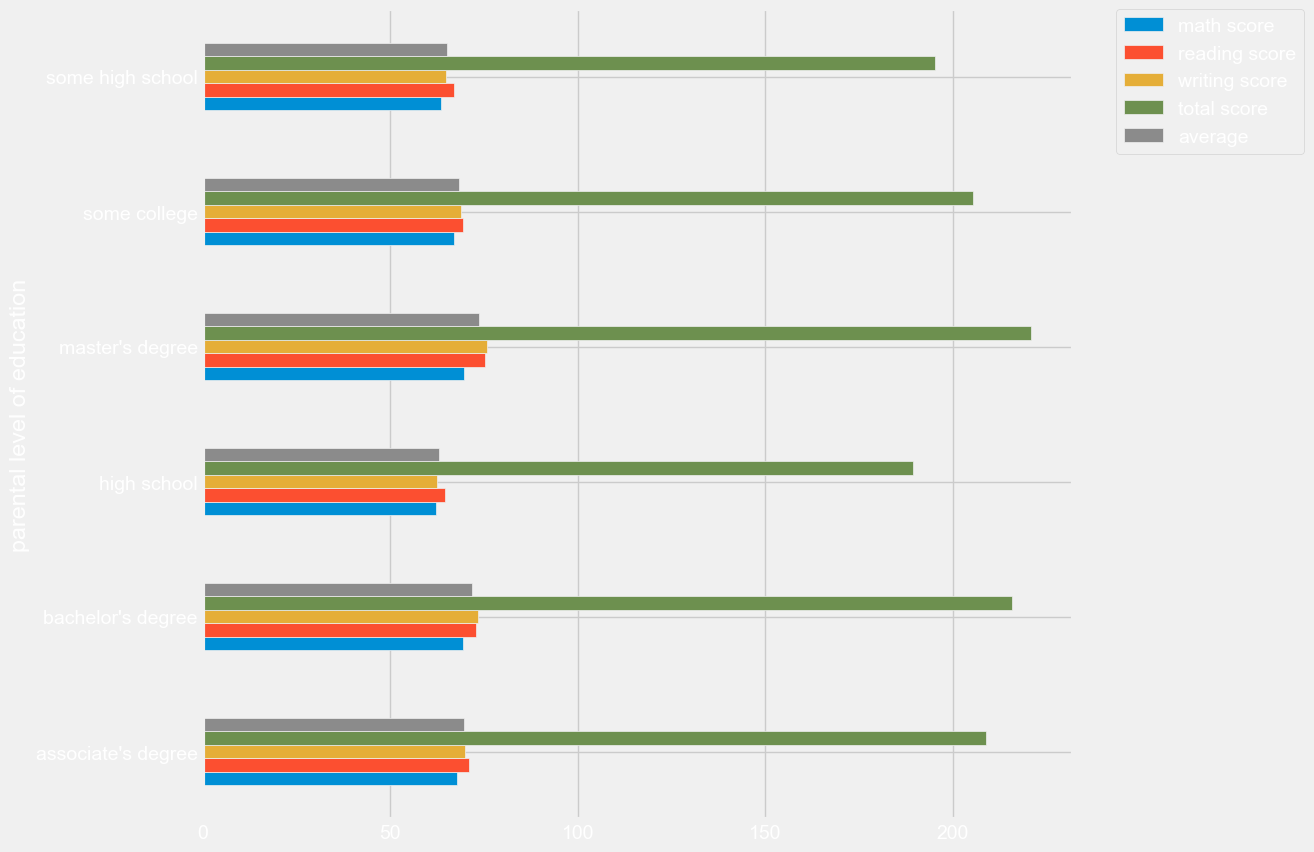

In [42]:
student_performance_data.groupby('parental level of education')\
    .mean(numeric_only=True)\
    .plot(kind='barh', figsize=(10,10))

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

#### Insights
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

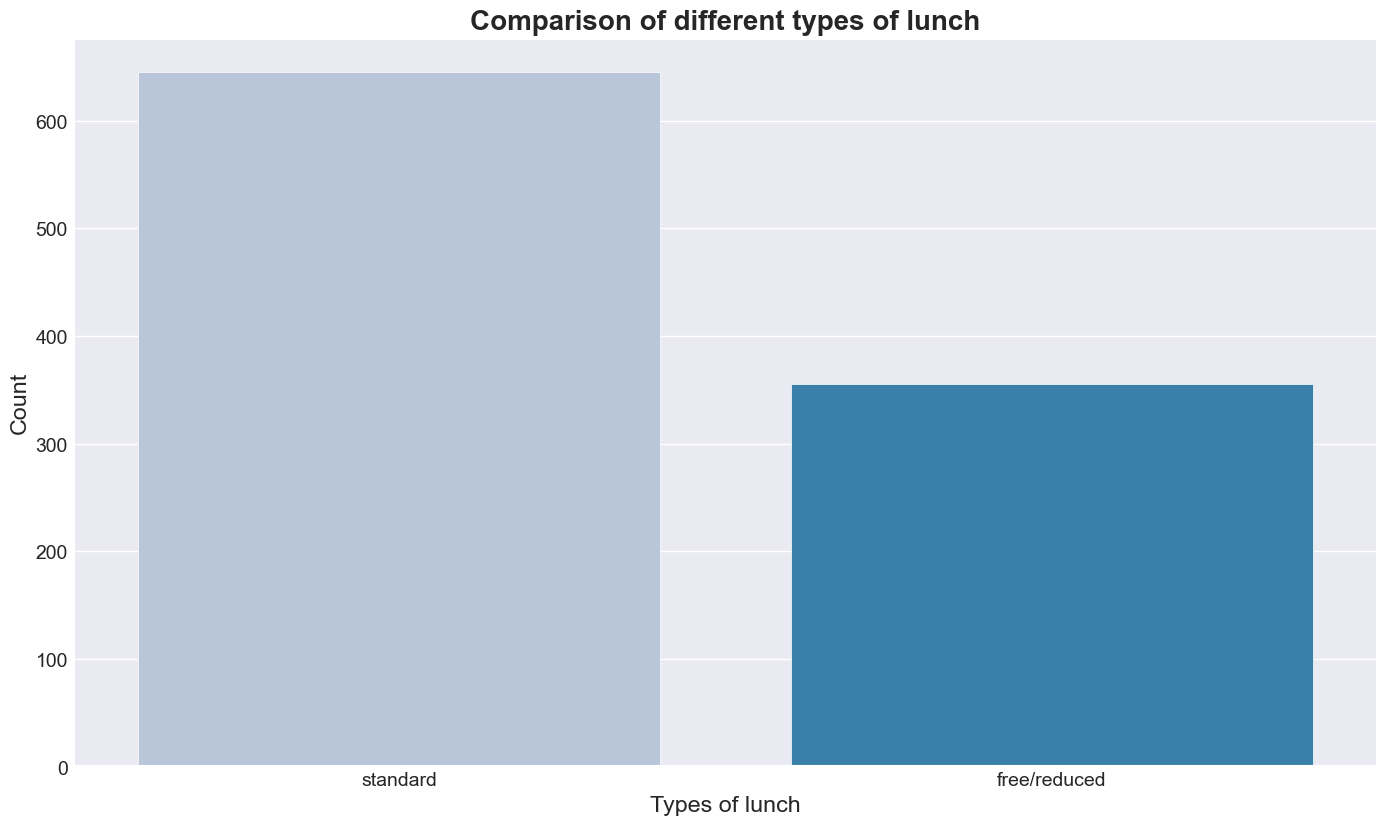

In [44]:
plt.rcParams['figure.figsize'] = (15, 9)

sns.set_style('darkgrid')  # better than plt.style.use

sns.countplot(
    x=student_performance_data['lunch'],
    palette='PuBu'
)

plt.title('Comparison of different types of lunch', fontweight='bold', fontsize=20)
plt.xlabel('Types of lunch')
plt.ylabel('Count')

plt.show()

### Insights

* More students are being served "Standard Lunch" than "Free/Reduced Lunch"

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

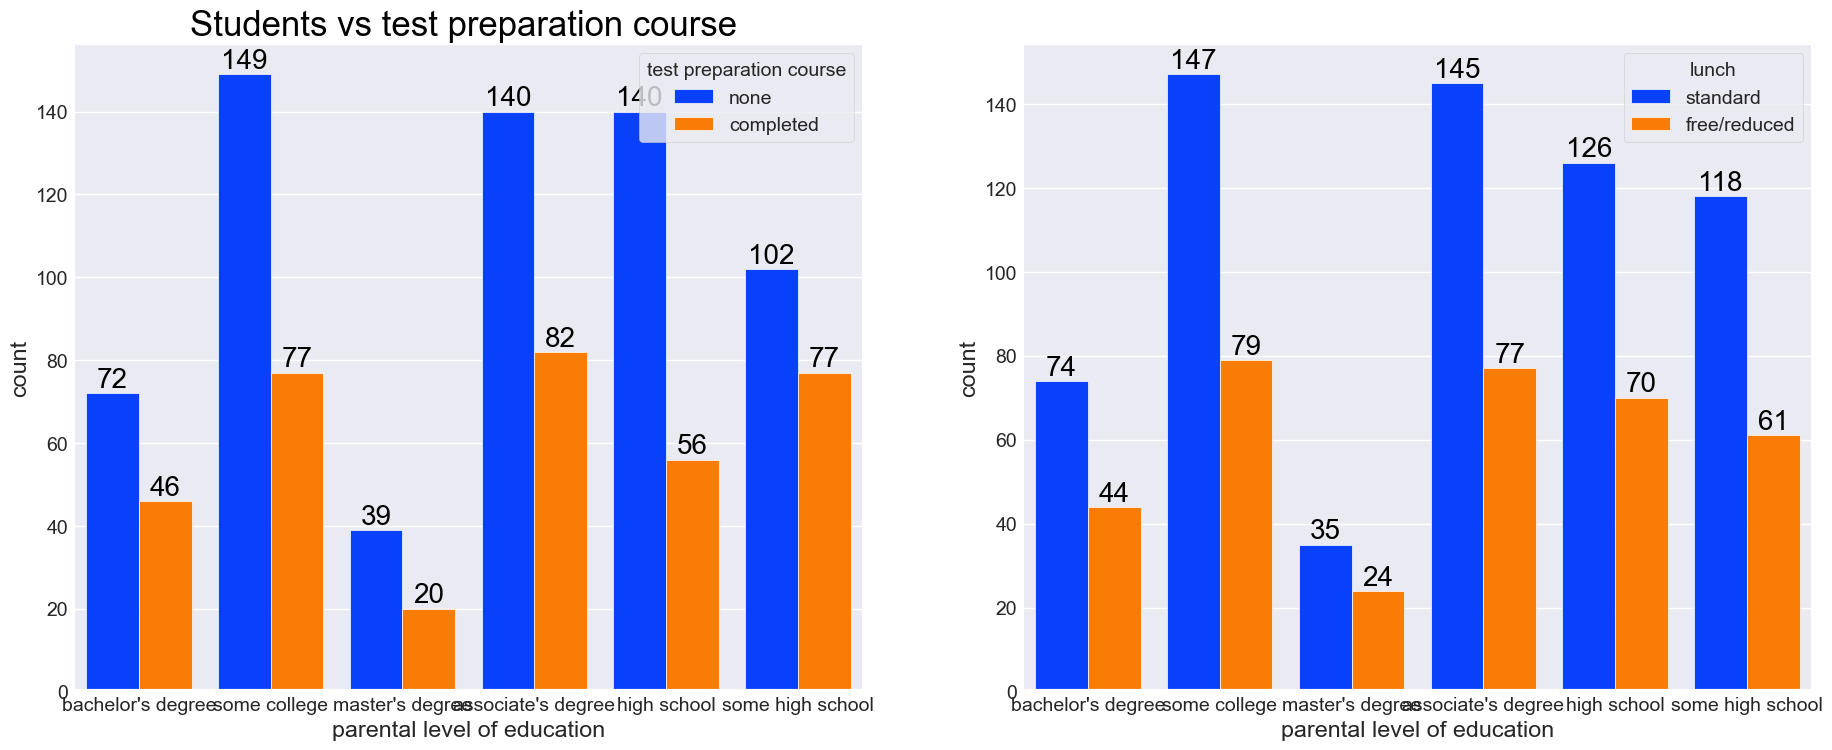

In [46]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=student_performance_data['parental level of education'],data=student_performance_data,palette = 'bright',hue='test preparation course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

sns.countplot(x=student_performance_data['parental level of education'],data=student_performance_data,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)

#### Insights
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

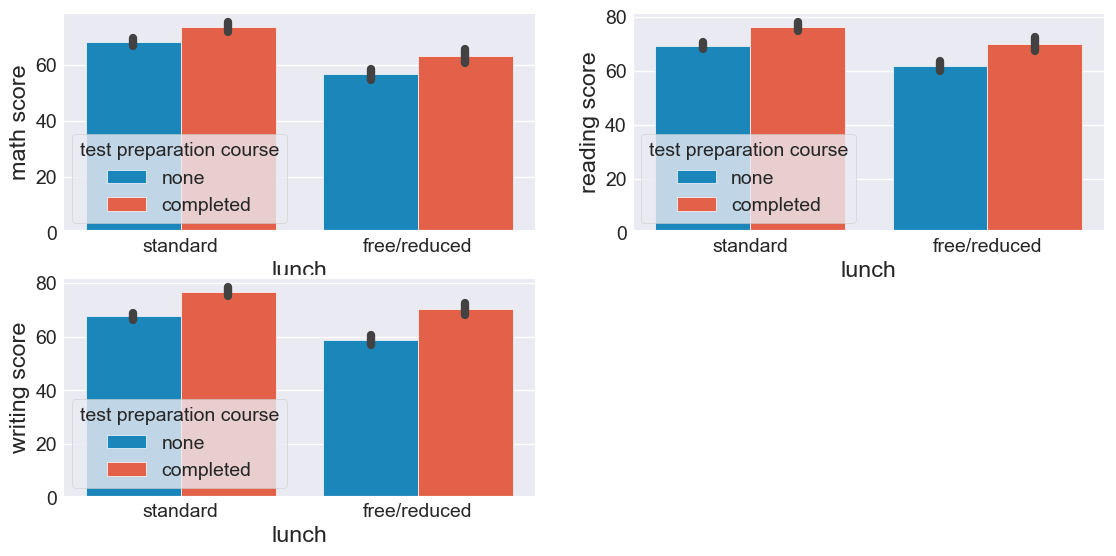

In [47]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=student_performance_data['lunch'], y=student_performance_data['math score'], hue=student_performance_data['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=student_performance_data['lunch'], y=student_performance_data['reading score'], hue=student_performance_data['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=student_performance_data['lunch'], y=student_performance_data['writing score'], hue=student_performance_data['test preparation course'])

#### Insights
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

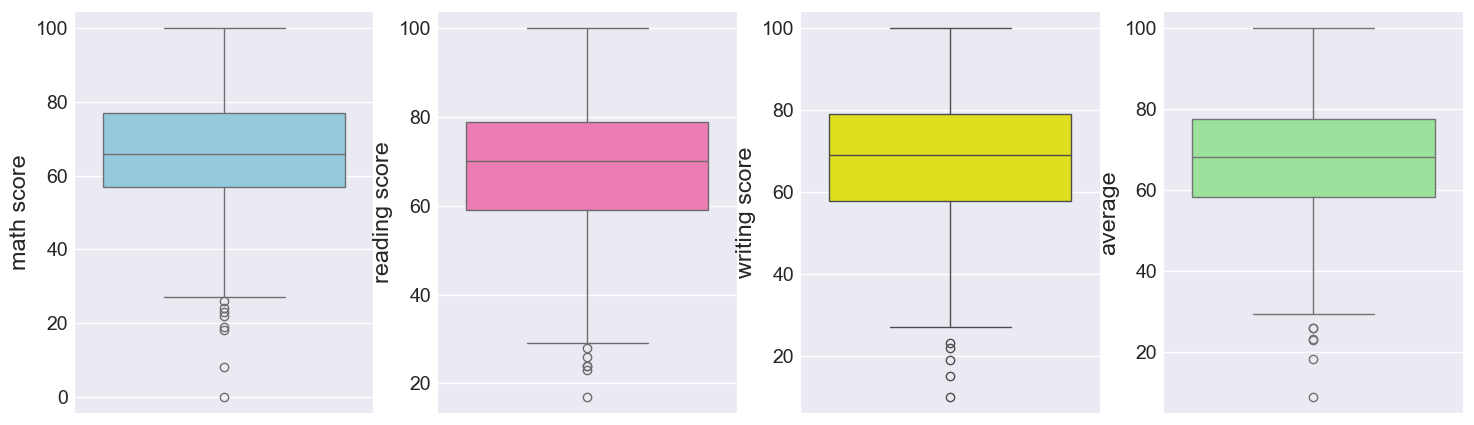

In [48]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(student_performance_data['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(student_performance_data['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(student_performance_data['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(student_performance_data['average'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

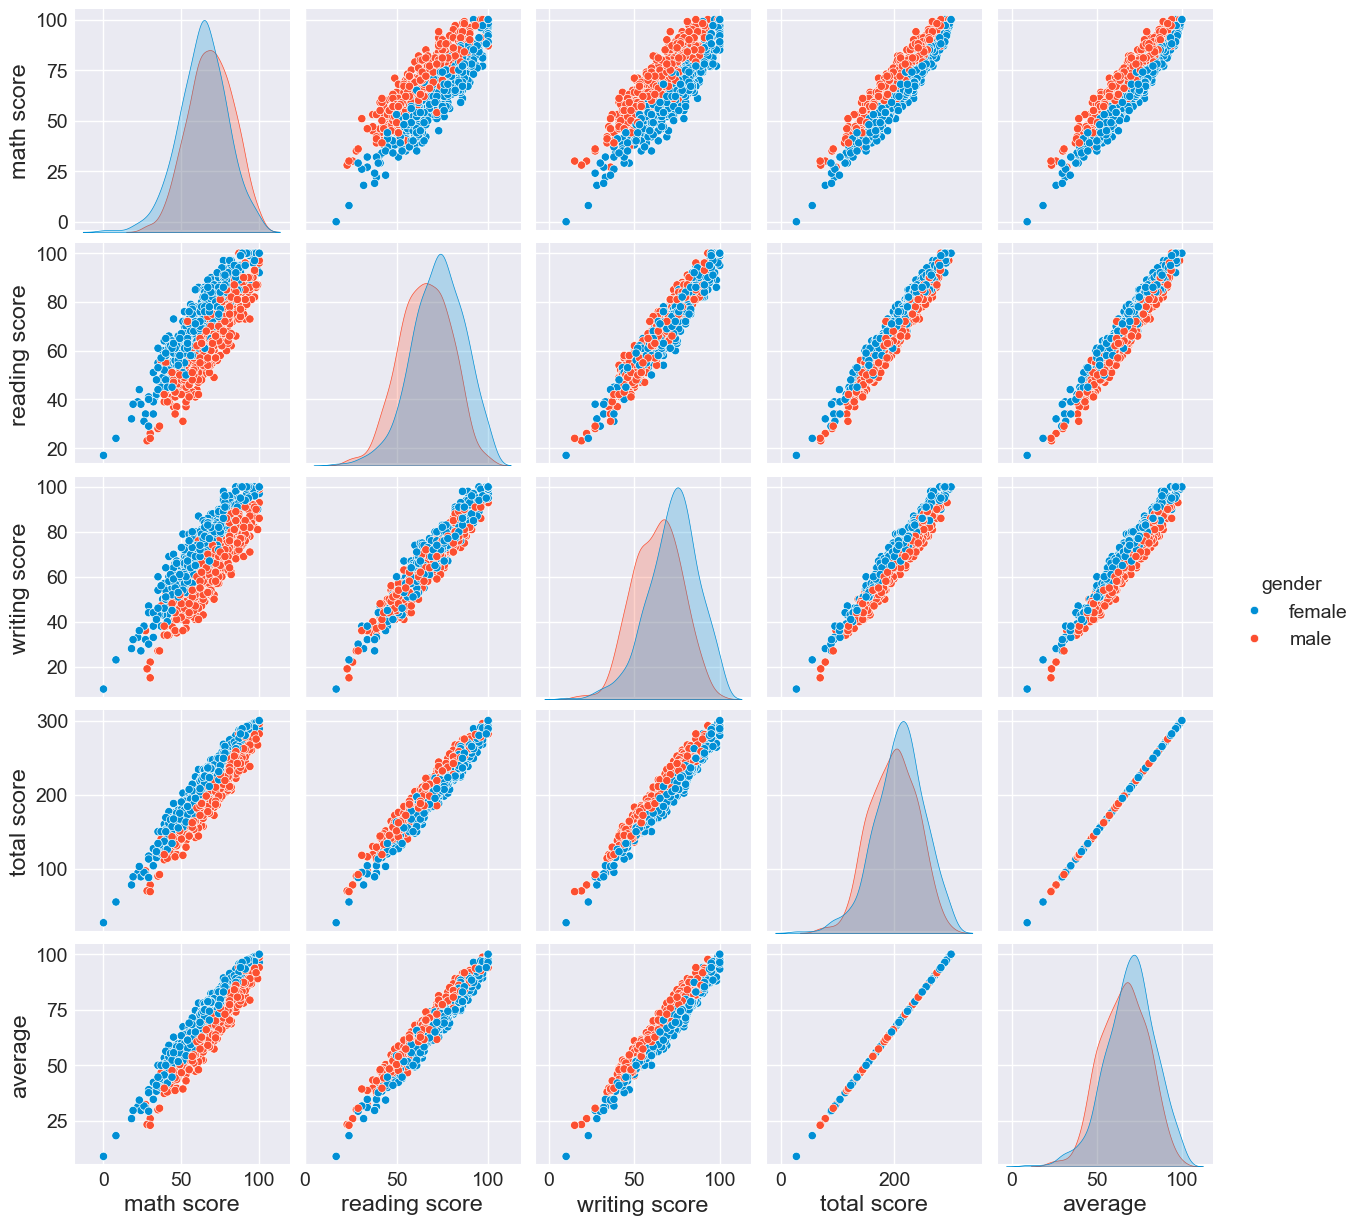

In [49]:
sns.pairplot(student_performance_data,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.